In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
path = "/kaggle/input/cars-for-sale/Updated_Car_Sales_Data.csv"

In [4]:
df = pd.read_csv(path)

In [5]:
df.head()

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident
0,Hyundai,Tucson,2010,52554,44143.820,Hybrid,Black,Automatic,Heated Seats,Used,No
1,Land Rover,Range Rover,2016,115056,25414.060,Diesel,Silver,Manual,GPS,Used,No
2,Honda,Accord,2022,18044,28262.872,Electric,Yellow,Manual,"Bluetooth, Leather Seats, Backup Camera, GPS",Like New,Yes
3,Kia,Soul,2011,79251,28415.848,Hybrid,Orange,Manual,"Backup Camera, GPS, Heated Seats, Leather Seats",New,Yes
4,Volkswagen,Golf,2022,40975,31509.792,Electric,Silver,Automatic,"Leather Seats, Remote Start, Sunroof, Heated S...",New,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23000 entries, 0 to 22999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car Make          23000 non-null  object 
 1   Car Model         23000 non-null  object 
 2   Year              23000 non-null  int64  
 3   Mileage           23000 non-null  int64  
 4   Price             23000 non-null  float64
 5   Fuel Type         23000 non-null  object 
 6   Color             23000 non-null  object 
 7   Transmission      23000 non-null  object 
 8   Options/Features  23000 non-null  object 
 9   Condition         23000 non-null  object 
 10  Accident          23000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ MB


In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
22995    False
22996    False
22997    False
22998    False
22999    False
Length: 23000, dtype: bool

In [8]:
df.duplicated().sum()

0

In [9]:
print(df.duplicated)

<bound method DataFrame.duplicated of            Car Make    Car Model  Year  Mileage       Price Fuel Type   Color  \
0           Hyundai       Tucson  2010    52554   44143.820    Hybrid   Black   
1        Land Rover  Range Rover  2016   115056   25414.060    Diesel  Silver   
2             Honda       Accord  2022    18044   28262.872  Electric  Yellow   
3               Kia         Soul  2011    79251   28415.848    Hybrid  Orange   
4        Volkswagen         Golf  2022    40975   31509.792  Electric  Silver   
...             ...          ...   ...      ...         ...       ...     ...   
22995  Aston Martin      Vantage  2021    46146  164033.000    Hybrid     Red   
22996  Aston Martin          DBX  2017    45415  213867.000    Hybrid   White   
22997       Porsche      Cayenne  2015    32402  145626.000    Petrol   Black   
22998   Lamborghini    Aventador  2020    27640  224705.000    Hybrid   White   
22999      Maserati      Levante  2016    20624  164375.000    Diesel  

In [10]:
df.isna().sum()

Car Make            0
Car Model           0
Year                0
Mileage             0
Price               0
Fuel Type           0
Color               0
Transmission        0
Options/Features    0
Condition           0
Accident            0
dtype: int64

In [11]:
df.describe(include='all')

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident
count,23000,23000,23000.000000,23000.000000,23000.000000,23000,23000,23000,23000,23000,23000
unique,29,120,NaN,NaN,NaN,5,10,2,1100,3,2
top,Porsche,Traverse,NaN,NaN,NaN,Hybrid,Blue,Automatic,Leather Seats,New,Yes
freq,1268,444,NaN,NaN,NaN,5764,2535,11549,1327,7721,18566
mean,NaN,NaN,2016.405826,71329.942696,46038.145075,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.756306,42973.351374,64252.736726,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2010.000000,5015.000000,4000.832000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2013.000000,33252.500000,14740.131000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,67282.500000,25489.812000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,108982.500000,36176.485000,NaN,NaN,NaN,NaN,NaN,NaN


**Modelling**

In [12]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
angka = df.select_dtypes(include = ['int64']).columns
df[angka] = scaler.fit_transform(df[angka])

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for x in df.columns:
    if df[x].dtype == 'object' :
        le = LabelEncoder()
        df[x] = le.fit_transform(df[x])
        label_encoders[x] = le

In [14]:
df.head()

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident
0,12,108,0.000000,0.327918,44143.820,3,0,0,471,2,0
1,16,93,0.461538,0.759050,25414.060,0,7,1,314,2,0
2,11,13,0.923077,0.089873,28262.872,1,9,1,238,0,1
3,14,101,0.076923,0.512071,28415.848,3,5,1,35,1,1
4,28,57,0.923077,0.248048,31509.792,1,7,0,758,1,1


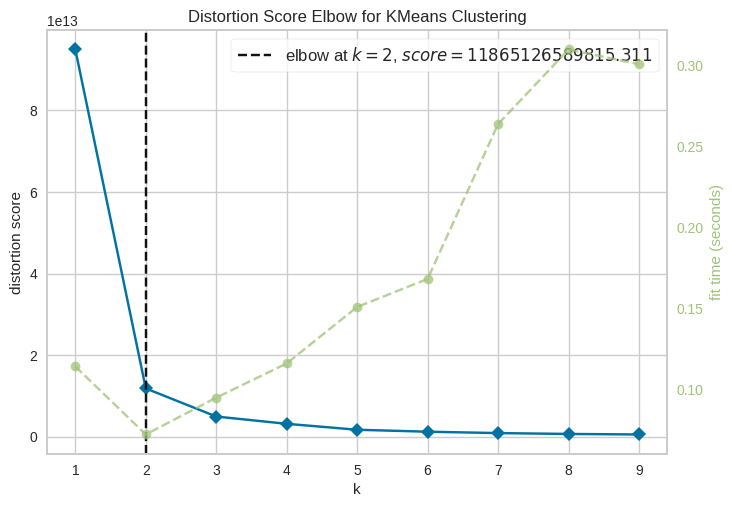

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [15]:
kmeans = KMeans()

visualizer = KElbowVisualizer(kmeans, k=(1, 10))

visualizer.fit(df)

visualizer.show()

In [16]:
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(df)

# Mendapatkan label cluster
labels = kmeans.labels_

# Jumlah cluster
k = 2


def analyze_clusters(df, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        
        cluster_data = df[labels == cluster_id]
        
        if len(cluster_data) == 0:  
            print(f"\nCluster {cluster_id + 1} tidak memiliki data.")
            continue

        mode_year = cluster_data['Year'].mode().values[0]
        mean_mileage = cluster_data['Mileage'].mean()
        mode_fueltype = cluster_data['Fuel Type'].mode().values[0]
        mode_transmission = cluster_data['Transmission'].mode().values[0]
        mode_accident = cluster_data['Accident'].mode().values[0]

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Tahun Paling Banyak: {mode_year:.2f}")
        print(f"Kilometer Rata-rata: {mean_mileage}")
        print(f"Bahan Bakar Umum: {mode_fueltype}")
        print(f"Transmisi Paling Umum: {mode_transmission}")
        print(f"Pernahnya Kecelakaan Secara Umum: {mode_accident}")

# Analisis karakteristik setiap cluster
analyze_clusters(df, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Tahun Paling Banyak: 0.77
Kilometer Rata-rata: 0.49812253224198394
Bahan Bakar Umum: 3
Transmisi Paling Umum: 0
Pernahnya Kecelakaan Secara Umum: 1

Cluster 2:
Tahun Paling Banyak: 0.85
Kilometer Rata-rata: 0.1579318145672733
Bahan Bakar Umum: 1
Transmisi Paling Umum: 1
Pernahnya Kecelakaan Secara Umum: 0


In [17]:
# Melihat Silhouette Score
silhouette_avg = silhouette_score(df, labels)
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.88


Selected Feature:  Index(['Year', 'Mileage', 'Fuel Type', 'Transmission', 'Accident'], dtype='object')


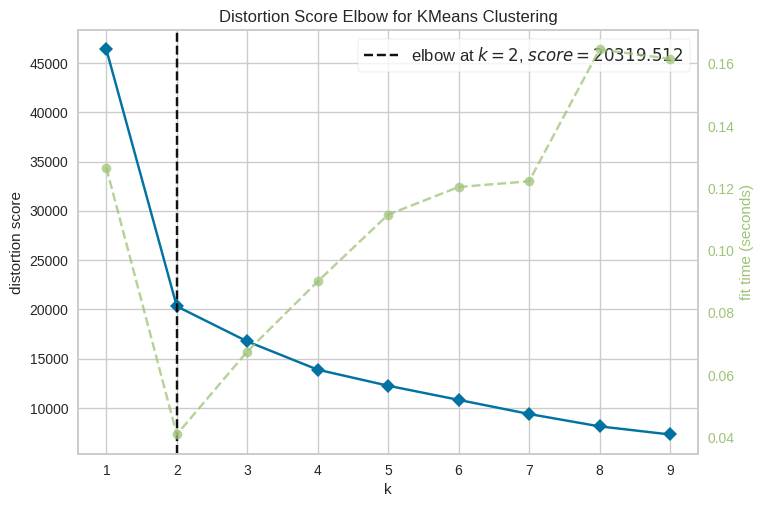

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
# Feature Selection Menggunakan Recursive Feature Elimination (RFE)
rfe = LogisticRegression(max_iter=500)
rfe_selector = RFE(rfe, n_features_to_select=5)
rfe_selector.fit(df, labels)

# Ambil fitur yang dipilih oleh RFE
selected_columns = df.columns[rfe_selector.support_]
print("Selected Feature: ",selected_columns)

visualizer_rfe = KElbowVisualizer(kmeans, k=(1, 10))
 
# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer_rfe.fit(df[selected_columns])
 
# Menampilkan grafik elbow untuk analisis
visualizer_rfe.show()

In [19]:
kmeans_rfe = df


kmeans_model_rfe = KMeans(n_clusters=2, random_state=0)
kmeans_model_rfe.fit(kmeans_rfe)

# Mendapatkan label cluster
labels_rfe = kmeans_model_rfe.labels_

silhouette_avg_rfe = silhouette_score(kmeans_rfe, labels_rfe)

print(f"silhouette score sebelum RFE : {silhouette_avg}")
print(f"silhouette score setelah RFE : {silhouette_avg_rfe}")

silhouette score sebelum RFE : 0.8832775321575097
silhouette score setelah RFE : 0.8832775321575097


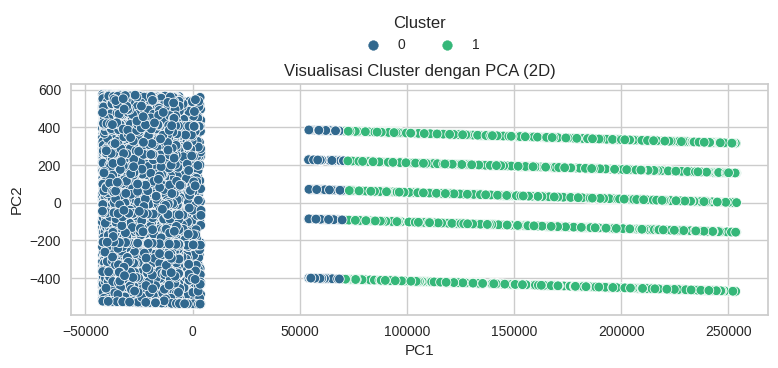

In [20]:
# Menampilkan hasil dalam visualisasi PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(kmeans_rfe)
df_viz = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
df_viz["cluster"] = labels_rfe

plt.figure(figsize=(9, 3))
sns.scatterplot(data=df_viz, x="PC1", y="PC2", hue="cluster", palette="viridis")
plt.title("Visualisasi Cluster dengan PCA (2D)")
plt.legend(title="Cluster", bbox_to_anchor=(0.5, 1.35), loc='upper center', ncol=3)
plt.show()

In [21]:
# Masukan label cluster ke data awal
df_normalized = kmeans_rfe.copy()
df_normalized["Cluster"] = labels_rfe
df_normalized.head()

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident,Cluster
0,12,108,0.000000,0.327918,44143.820,3,0,0,471,2,0,0
1,16,93,0.461538,0.759050,25414.060,0,7,1,314,2,0,0
2,11,13,0.923077,0.089873,28262.872,1,9,1,238,0,1,0
3,14,101,0.076923,0.512071,28415.848,3,5,1,35,1,1,0
4,28,57,0.923077,0.248048,31509.792,1,7,0,758,1,1,0


In [22]:
# Lakukan invers transform untuk data kategorikal
categorical_features = ['Fuel Type', 'Transmission', 'Accident']
for col in categorical_features:
    df_normalized[col] = label_encoders[col].inverse_transform(df_normalized[col])

In [23]:
df_normalized.head()

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident,Cluster
0,12,108,0.000000,0.327918,44143.820,Hybrid,0,Automatic,471,2,No,0
1,16,93,0.461538,0.759050,25414.060,Diesel,7,Manual,314,2,No,0
2,11,13,0.923077,0.089873,28262.872,Electric,9,Manual,238,0,Yes,0
3,14,101,0.076923,0.512071,28415.848,Hybrid,5,Manual,35,1,Yes,0
4,28,57,0.923077,0.248048,31509.792,Electric,7,Automatic,758,1,Yes,0


In [24]:
# Lakukan invers transform untuk data numerik
df[angka] = scaler.inverse_transform(df[angka])

numeric_features_rfe = ['Year', 'Mileage']
df_normalized[numeric_features_rfe] = df[numeric_features_rfe]

In [25]:
df_normalized.head()

,Car Make,Car Model,Year,Mileage,Price,Fuel Type,Color,Transmission,Options/Features,Condition,Accident,Cluster
0,12,108,2010.0,52554.0,44143.820,Hybrid,0,Automatic,471,2,No,0
1,16,93,2016.0,115056.0,25414.060,Diesel,7,Manual,314,2,No,0
2,11,13,2022.0,18044.0,28262.872,Electric,9,Manual,238,0,Yes,0
3,14,101,2011.0,79251.0,28415.848,Hybrid,5,Manual,35,1,Yes,0
4,28,57,2022.0,40975.0,31509.792,Electric,7,Automatic,758,1,Yes,0


In [26]:
# Analisis Cluster
def analyze_clusters(df_normalized, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        
        cluster_data = df_normalized[labels == cluster_id]
        
        if len(cluster_data) == 0:  
            print(f"\nCluster {cluster_id + 1} tidak memiliki data.")
            continue

        mode_year = cluster_data['Year'].mode().values[0]
        mean_mileage = cluster_data['Mileage'].mean()
        mode_fueltype = cluster_data['Fuel Type'].mode().values[0]
        mode_transmission = cluster_data['Transmission'].mode().values[0]
        mode_accident = cluster_data['Accident'].mode().values[0]

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Tahun Paling Banyak: {mode_year:.2f}")
        print(f"Kilometer Rata-rata: {mean_mileage}")
        print(f"Bahan Bakar Umum: {mode_fueltype}")
        print(f"Transmisi Paling Umum: {mode_transmission}")
        print(f"Pernahnya Kecelakaan Secara Umum: {mode_accident}")

# Analisis karakteristik setiap cluster
analyze_clusters(df_normalized, labels_rfe, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Tahun Paling Banyak: 2020.00
Kilometer Rata-rata: 77228.8197441849
Bahan Bakar Umum: Hybrid
Transmisi Paling Umum: Automatic
Pernahnya Kecelakaan Secara Umum: Yes

Cluster 2:
Tahun Paling Banyak: 2021.00
Kilometer Rata-rata: 27910.691021446746
Bahan Bakar Umum: Electric
Transmisi Paling Umum: Manual
Pernahnya Kecelakaan Secara Umum: No


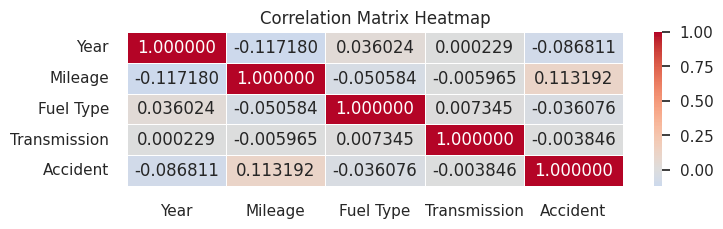

In [27]:
import seaborn as sns
sns.set_theme(style="whitegrid")
numerical_features = ['Year', 'Mileage', 'Fuel Type', 'Transmission', 'Accident']

correlation_matrix = df[numerical_features].corr()
correlation_matrix.style.background_gradient(cmap="coolwarm")

sns.set_theme(style="white")

plt.figure(figsize=(8, 2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".6f")
plt.title('Correlation Matrix Heatmap')
plt.show()
